# EXCERISE 2: Optimal control in Jump

In [11]:
using DifferentialEquations
using Optim
using Pkg
using Revise
using HarmonicSolvers
using LinearAlgebra
using Plots
using JuMP, Ipopt
using CairoMakie

In [3]:
@kwdef struct CartpoleParameters
    cart_mass::Float64 = 1.0
    pole_mass::Float64 = 0.2
    pole_length::Float64 = 0.5
    gravity::Float64 = 9.81
    damping::Float64 = 0.05
    maximum_force::Float64 = 10.0
    track_limit::Float64 = 2.4
end


CartpoleParameters

In [4]:
const POSITION = 1
const ANGLE = 2
const VELOCITY = 3
const ANGULAR_VELOCITY = 4
const FORCE = 1

1

In [5]:
function cartpole_dynamics(x, u, p, t)
    q, θ, q̇, θ̇ = x
    force = u[FORCE]
    s = sin(θ)
    c = cos(θ)
    denominator = p.cart_mass + p.pole_mass * s^2
    q̈ = (
        force - p.damping * q̇ +
        p.pole_mass * s * (p.pole_length * θ̇^2 + p.gravity * c)
    ) / denominator
    θ̈ = -(q̈ * c + p.gravity * s) / p.pole_length
    return [q̇, θ̇, q̈, θ̈]
end

cartpole_dynamics (generic function with 1 method)

In [6]:
#X[i, k] is state component i at knot k
#U[j, k] is control component j over interval k (ZOH)
N = 81
duration = 4.0
times = LinRange(0, duration, N)
dt = times[2] - times[1]

# Create the initial state of the pole at the bottom.
# The goal is to swing the pole from the bottom to the top while returning the cart to the origin.
inital_state = [0.0, 0.0, 0.0, 0.0]
goal_state = [0.0, π, 0.0, 0.0]
(nx, nu) = (4, 1)

model = Model(Ipopt.Optimizer)
set_optimizer_attribute(model, "max_iter", 3_000)

# Use @variable to add matrix variables to the model
# size(X) = (nx, N)
# size(U) = (nu, N-1)
@variable(model, X[1:nx, 1:N])
@variable(model, U[1:nu, 1:(N - 1)])


1×80 Matrix{VariableRef}:
 U[1,1]  U[1,2]  U[1,3]  U[1,4]  …  U[1,77]  U[1,78]  U[1,79]  U[1,80]


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:     1288
Number of nonzeros in inequality constraint Jacobian.:      161
Number of nonzeros in Lagrangian Hessian.............:     1200

Total number of variables............................:      404
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      328
Total number of inequality c

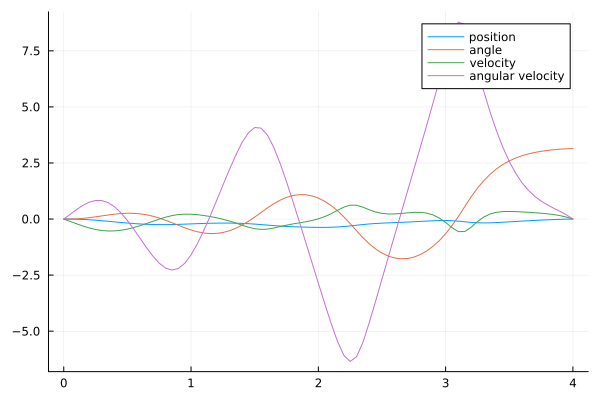

In [ ]:
p = CartpoleParameters()

for k in 1:(N - 1)
    state_k = [X[POSITION, k], X[ANGLE, k], X[VELOCITY, k], X[ANGULAR_VELOCITY, k]]
    control_k = [U[FORCE, k]]
    predicted_state = state_k .+ dt .* cartpole_dynamics(state_k, control_k, p, times[k])
    for i in 1:nx
        @NLconstraint(model, X[i, k + 1] == predicted_state[i])
    end
end

#=
Compare: (θ−π)^2 versus 1−cos(θ−π)
make sure X stays on the track
make sure the controls stay inside the force limits
fix the initial state
Note: Instead of the objective, you could fix the final state, and make the cost just
regulation on force
=#
for k in 1:N
    @constraint(model, -p.track_limit <= X[POSITION, k] <= p.track_limit)
end
for k in 1:(N - 1)
    @constraint(model, -p.maximum_force <= U[FORCE, k] <= p.maximum_force)
end

@constraint(model, X[POSITION, 1] == inital_state[POSITION])
@constraint(model, X[ANGLE, 1] == inital_state[ANGLE])
@constraint(model, X[VELOCITY, 1] == inital_state[VELOCITY])
@constraint(model, X[ANGULAR_VELOCITY, 1] == inital_state[ANGULAR_VELOCITY])

@constraint(model, X[POSITION, N] == goal_state[POSITION])
@constraint(model, X[ANGLE, N] == goal_state[ANGLE])
@constraint(model, X[VELOCITY, N] == goal_state[VELOCITY])
@constraint(model, X[ANGULAR_VELOCITY, N] == goal_state[ANGULAR_VELOCITY])

@objective(model, Min, sum(U[FORCE, k]^2 for k in 1:(N - 1)))

optimize!(model)

if termination_status(model) == MOI.OPTIMAL || termination_status(model) == MOI.LOCALLY_SOLVED
    state_solution = value.(X)
    control_solution = value.(U)
    plot(times, state_solution[POSITION, :], label = "position", legend = :topright)
    plot!(times, state_solution[ANGLE, :], label = "angle")
    plot!(times, state_solution[VELOCITY, :], label = "velocity")
    plot!(times, state_solution[ANGULAR_VELOCITY, :], label = "angular velocity")
end


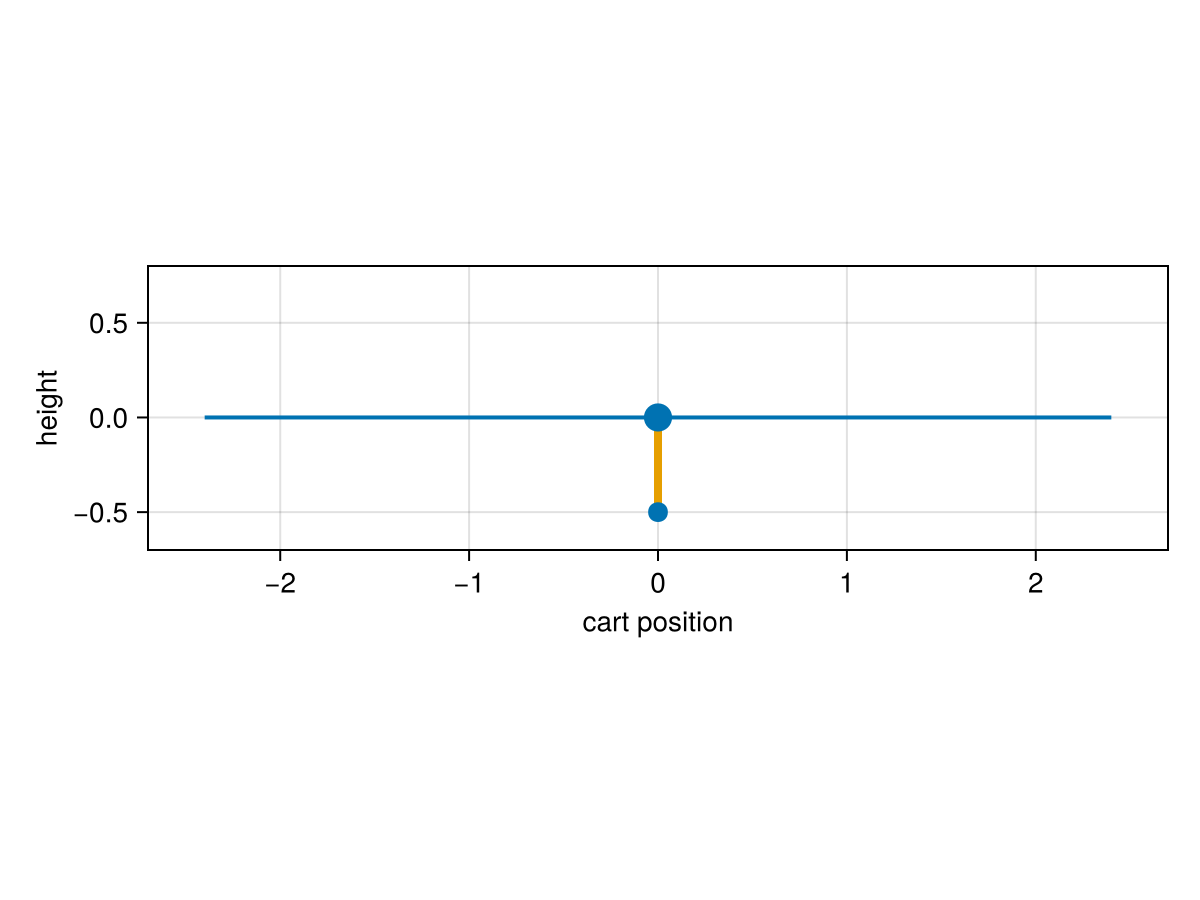

In [13]:
function draw_cartpole(state, p::CartpoleParameters)
    q, θ = state[POSITION], state[ANGLE]
    tip = Point2f(
        q + p.pole_length * sin(θ),
        -p.pole_length * cos(θ),
    )

    fig = Figure()
    ax = Axis(
        fig[1, 1];
        xlabel = "cart position",
        ylabel = "height",
        aspect = DataAspect(),
        limits = (
            -p.track_limit - 0.3,
            p.track_limit + 0.3,
            -p.pole_length - 0.2,
            p.pole_length + 0.3,
        ),
    )

    lines!(ax, [-p.track_limit, p.track_limit], [0, 0]; linewidth = 2)
    lines!(ax, [Point2f(q, 0), tip]; linewidth = 4)
    CairoMakie.scatter!(ax, [Point2f(q, 0), tip]; markersize = [20, 14])

    return fig
end

draw_cartpole(state_solution, p)